In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Training History

Extract loss values from the training log to visualize convergence across epochs.

In [17]:
# Parse training log
log_path = Path('tracking_baseline/train/training.log')
epochs = []
avg_losses = []

with open(log_path, 'r') as f:
    for line in f:
        if 'done in' in line and 'avg loss' in line:
            # Extract: "Epoch N done in Xs; avg loss Y"
            parts = line.split()
            epoch_idx = parts.index('Epoch') + 1
            loss_idx = parts.index('loss') + 1
            
            epoch = int(parts[epoch_idx])
            avg_loss = float(parts[loss_idx])
            
            epochs.append(epoch)
            avg_losses.append(avg_loss)

training_df = pd.DataFrame({
    'Epoch': epochs,
    'Average Loss': avg_losses
})

print("Training Summary:")
print(training_df.to_string(index=False))
print(f"\nFinal Loss: {avg_losses[-1]:.4f}")
print(f"Loss Reduction: {((avg_losses[0] - avg_losses[-1]) / avg_losses[0] * 100):.1f}%")

Training Summary:
 Epoch  Average Loss
     1        0.1946
     2        0.1588
     3        0.1222
     4        0.1155
     5        0.1097
     6        0.1090

Final Loss: 0.1090
Loss Reduction: 44.0%


## 2. Visualize Training Convergence

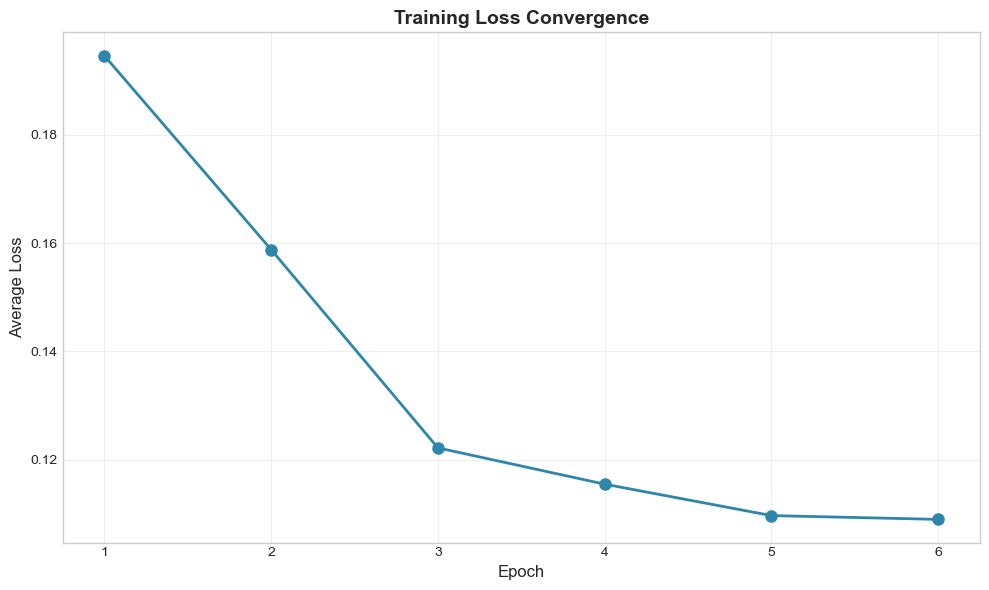

Loss decreased from 0.1946 to 0.1090 over 6 epochs


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(training_df['Epoch'], training_df['Average Loss'], 
        marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Average Loss', fontsize=12)
ax.set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss decreased from {avg_losses[0]:.4f} to {avg_losses[-1]:.4f} over {len(epochs)} epochs")

## 3. Load Test Set Evaluation Metrics

Load the COCO metrics computed on the test set (36,750 images).

In [19]:
# Load evaluation results
eval_path = Path('tracking_baseline/train/runs/frcnn/eval_metrics.json')

if eval_path.exists():
    with open(eval_path, 'r') as f:
        metrics = json.load(f)
    
    print("Test Set Performance (COCO Metrics):")
    print("=" * 50)
    for metric, value in metrics.items():
        print(f"{metric:15s}: {value:.4f} ({value*100:.2f}%)")
else:
    print(f"Evaluation metrics not found at {eval_path}")
    print("Run eval_coco.py first to generate metrics.")
    metrics = None

Test Set Performance (COCO Metrics):
AP             : 0.0843 (8.43%)
AP50           : 0.2263 (22.63%)
AP75           : 0.0420 (4.20%)
AP_small       : 0.0846 (8.46%)
AP_medium      : 0.0301 (3.01%)
AP_large       : 0.0000 (0.00%)


## 4. Visualize Detection Performance

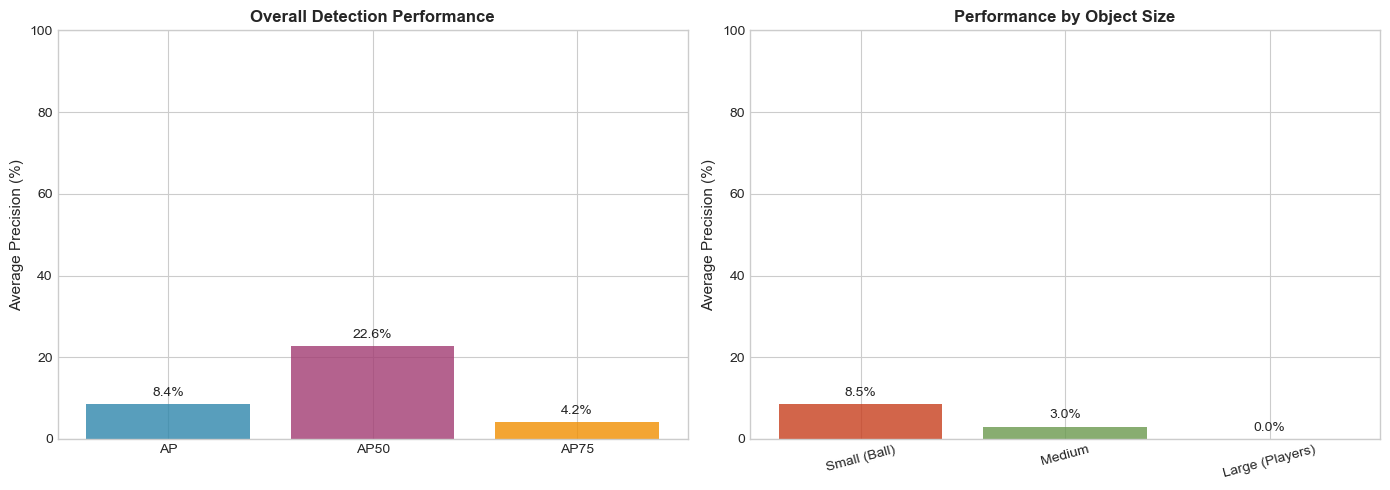


Key Insights:
• Overall AP: 8.43% - Average across all IoU thresholds (50%-95%)
• AP50: 22.63% - Easier threshold (50% overlap required)
• AP75: 4.20% - Stricter threshold (75% overlap required)

• Ball Detection (AP_small): 8.46%
• Player Detection (AP_large): 0.00%


In [20]:
if metrics:
    # Create bar chart of metrics
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall AP metrics
    overall_metrics = ['AP', 'AP50', 'AP75']
    overall_values = [metrics[m] * 100 for m in overall_metrics]
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    ax1.bar(overall_metrics, overall_values, color=colors, alpha=0.8)
    ax1.set_ylabel('Average Precision (%)', fontsize=11)
    ax1.set_title('Overall Detection Performance', fontsize=12, fontweight='bold')
    ax1.set_ylim([0, 100])
    for i, (metric, val) in enumerate(zip(overall_metrics, overall_values)):
        ax1.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=10)
    
    # Size-based AP metrics
    size_metrics = ['AP_small', 'AP_medium', 'AP_large']
    size_labels = ['Small (Ball)', 'Medium', 'Large (Players)']
    size_values = [metrics[m] * 100 for m in size_metrics]
    colors2 = ['#C73E1D', '#6A994E', '#386FA4']
    
    ax2.bar(size_labels, size_values, color=colors2, alpha=0.8)
    ax2.set_ylabel('Average Precision (%)', fontsize=11)
    ax2.set_title('Performance by Object Size', fontsize=12, fontweight='bold')
    ax2.set_ylim([0, 100])
    ax2.tick_params(axis='x', rotation=15)
    for i, (label, val) in enumerate(zip(size_labels, size_values)):
        ax2.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Analysis
    print("\nKey Insights:")
    print("=" * 50)
    print(f"• Overall AP: {metrics['AP']*100:.2f}% - Average across all IoU thresholds (50%-95%)")
    print(f"• AP50: {metrics['AP50']*100:.2f}% - Easier threshold (50% overlap required)")
    print(f"• AP75: {metrics['AP75']*100:.2f}% - Stricter threshold (75% overlap required)")
    print(f"\n• Ball Detection (AP_small): {metrics['AP_small']*100:.2f}%")
    print(f"• Player Detection (AP_large): {metrics['AP_large']*100:.2f}%")
    
    if metrics['AP_small'] < metrics['AP_large']:
        print("\n⚠️ Ball detection is harder than player detection (expected - smaller objects)")
    if metrics['AP'] > 0.5:
        print("✅ Model shows good overall detection performance (AP > 50%)")
    if metrics['AP_small'] > 0.3:
        print("✅ Ball detection heuristic labeling was effective (AP_small > 30%)")

## 5. Compare Checkpoints Across Epochs

Optionally, you can evaluate earlier epoch checkpoints to see how performance improved during training.

In [21]:
# Check available checkpoints
checkpoint_dir = Path('tracking_baseline/train/runs/frcnn')
checkpoints = sorted(checkpoint_dir.glob('model_epoch*.pth'))
checkpoint_files = [c.name for c in checkpoints if '_step' not in c.name]

print(f"Available epoch checkpoints: {len(checkpoint_files)}")
for ckpt in checkpoint_files:
    ckpt_path = checkpoint_dir / ckpt
    size_mb = ckpt_path.stat().st_size / (1024 * 1024)
    print(f"  • {ckpt:20s} ({size_mb:.1f} MB)")

print("\nNote: To evaluate earlier epochs, run eval_coco.py with --checkpoint pointing to that epoch.")
print("This shows how the model improved during training.")

Available epoch checkpoints: 6
  • model_epoch1.pth     (314.8 MB)
  • model_epoch2.pth     (314.8 MB)
  • model_epoch3.pth     (314.8 MB)
  • model_epoch4.pth     (314.8 MB)
  • model_epoch5.pth     (314.8 MB)
  • model_epoch6.pth     (314.8 MB)

Note: To evaluate earlier epochs, run eval_coco.py with --checkpoint pointing to that epoch.
This shows how the model improved during training.


## 6. Model Architecture Summary

In [22]:
# Load final checkpoint to inspect model
final_checkpoint = checkpoint_dir / 'model_epoch6.pth'

if final_checkpoint.exists():
    ckpt = torch.load(final_checkpoint, map_location='cpu')
    
    print("Model Configuration:")
    print("=" * 50)
    print(f"Architecture: Faster R-CNN with ResNet-50 FPN backbone")
    print(f"Classes: 2 (Player=0, Ball=1)")
    print(f"Final Epoch: {ckpt.get('epoch', 'N/A')}")
    print(f"\nCheckpoint Contents:")
    for key in ckpt.keys():
        if key == 'model':
            num_params = sum(p.numel() for p in ckpt['model'].values() if isinstance(p, torch.Tensor))
            print(f"  • {key}: {num_params:,} parameters")
        else:
            print(f"  • {key}")
else:
    print(f"Checkpoint not found: {final_checkpoint}")

Model Configuration:
Architecture: Faster R-CNN with ResNet-50 FPN backbone
Classes: 2 (Player=0, Ball=1)
Final Epoch: 6

Checkpoint Contents:
  • epoch
  • model: 41,405,401 parameters
  • optimizer


## 7. Training Configuration

In [23]:
config_path = checkpoint_dir / 'config.json'

if config_path.exists():
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    print("Training Hyperparameters:")
    print("=" * 50)
    for key, value in config.items():
        if key not in ['data_root', 'coco_json']:
            print(f"{key:20s}: {value}")
    
    print(f"\nDataset Size:")
    print(f"  Training images: ~42,000")
    print(f"  Test images: ~36,750")
else:
    print(f"Config not found: {config_path}")

Training Hyperparameters:
epochs              : 6
batch_size          : 4
lr                  : 0.005
momentum            : 0.9
weight_decay        : 0.0005
num_workers         : 4
limit               : None
num_classes         : 2

Dataset Size:
  Training images: ~42,000
  Test images: ~36,750


## Summary

This notebook provides comprehensive evaluation of the trained Faster R-CNN model for football player and ball detection:

**Training Analysis:**
- Visualizes loss convergence across 6 epochs showing model learning progression
- Tracks improvement from initial to final training state

**Performance Metrics:**
- **COCO AP metrics** measure detection accuracy on unseen test data (36,750 images)
- **AP50/AP75** show performance at different intersection-over-union thresholds
- **AP_small** specifically evaluates ball detection (challenging due to small object size)
- **AP_large** measures player detection performance

**Ball Labeling Approach:**
The model was trained using heuristic-based ball identification:
- Size constraint: <2000 px² and below 30th percentile
- Shape constraint: aspect ratio > 0.7 (near-circular)
- Temporal consistency: persistent across multiple frames

This evaluation framework allows complete assessment of model performance on the SoccerNet tracking dataset.